# Projet Deep Learning - Partie II : CNN

**Dataset :** Fashion-MNIST — 70 000 images 28x28 en niveaux de gris, 10 classes de vêtements


## 1. Pourquoi le MLP marche mal sur les images ?

Le MLP traite chaque pixel comme une valeur indépendante. Pour une image 28x28, ça fait 784 valeurs.
Le problème c'est qu'il perd complètement l'information spatiale : il ne sait pas que deux pixels voisins sont reliés.
En plus, si l'image est décalée d'un pixel, le MLP la voit comme complètement différente.

Les CNN sont conçus pour régler ça : les filtres détectent des motifs locaux (bords, textures)
et les mêmes filtres sont réutilisés partout dans l'image, ce qui réduit énormément le nombre de paramètres.


## 2. Calculs manuels des tailles de sortie

Quelques formules utiles :

**Taille de sortie apres une convolution :**

H_{out} = \lfloor (H_{in} + 2P - K) / S \rfloor + 1

ou H = hauteur, P = padding, K = kernel size, S = stride.

**Exemple concret :** entree 28x28, kernel 5x5, padding=2, stride=1  
=> (28 + 4 - 5) / 1 + 1 = **28** (la taille est conservee grace au padding)

**Taille apres Max Pooling 2x2 :**  
H_out = H_in / 2 (arrondi vers le bas)  
28 -> 14 -> 5 au fil des couches


## 3. Chargement du dataset Fashion-MNIST


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

CLASS_NAMES = ['T-shirt', 'Pantalon', 'Pull', 'Robe', 'Manteau',
               'Sandale', 'Chemise', 'Basket', 'Sac', 'Bottine']

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(root='data', train=True,  download=True, transform=transform)
test_data  = datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)

# Split train → train + val (85% / 15%)
val_size   = int(0.15 * len(train_data))
train_size = len(train_data) - val_size
train_set, val_set = torch.utils.data.random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

print(f'Train : {len(train_set)} | Val : {len(val_set)} | Test : {len(test_data)}')

Device : cpu


100%|██████████| 26.4M/26.4M [00:21<00:00, 1.25MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 680kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.47MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 1.25MB/s]


Train : 51000 | Val : 9000 | Test : 10000


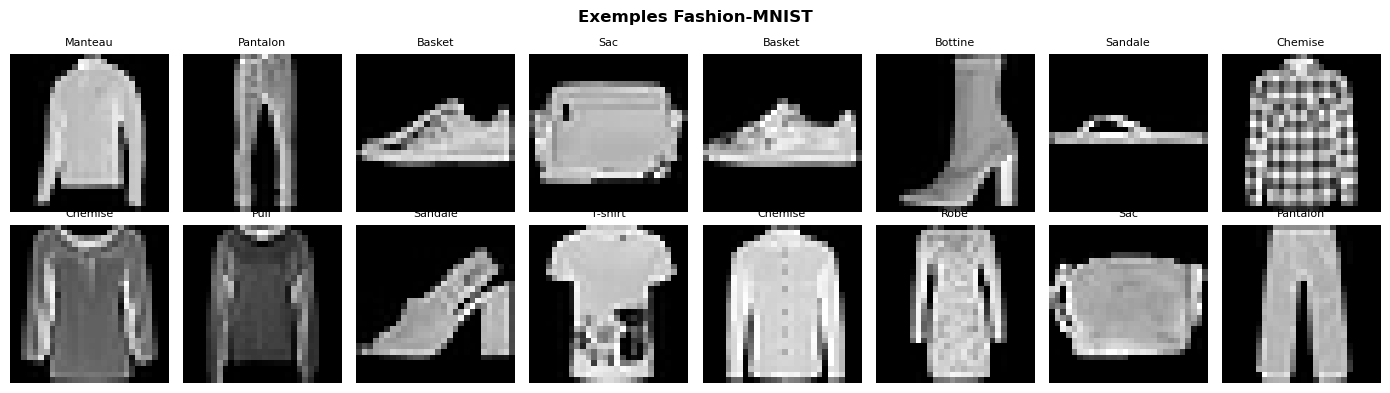

Shape image : torch.Size([1, 28, 28])  (C×H×W)


In [2]:
# Visualisation de quelques exemples
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Exemples Fashion-MNIST', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Shape image : {imgs[0].shape}  (C×H×W)')

## 4. Implémentations manuelles (NumPy)

### 4.1 Corrélation croisée 2D

La corrélation croisée est l'opération de base d'une couche convolutionnelle :
le filtre glisse sur l'image et à chaque position, on calcule le produit scalaire
entre le filtre et la région locale de l'image :

$$\text{Output}[i, j] = \sum_{m=0}^{K-1} \sum_{n=0}^{K-1} \text{Input}[i+m,\, j+n] \times \text{Kernel}[m, n]$$

In [3]:
def corr2d_manual(X, K):
    """Corrélation croisée 2D sans padding, stride=1."""
    h, w   = X.shape
    kh, kw = K.shape
    oh, ow = h - kh + 1, w - kw + 1
    Y = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            Y[i, j] = np.sum(X[i:i+kh, j:j+kw] * K)
    return Y


def max_pool2d_manual(X, pool_size=2):
    """Max-pooling 2D (stride = pool_size)."""
    h, w = X.shape
    oh, ow = h // pool_size, w // pool_size
    Y = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            Y[i, j] = np.max(X[i*pool_size:(i+1)*pool_size,
                               j*pool_size:(j+1)*pool_size])
    return Y


def avg_pool2d_manual(X, pool_size=2):
    """Average-pooling 2D (stride = pool_size)."""
    h, w = X.shape
    oh, ow = h // pool_size, w // pool_size
    Y = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            Y[i, j] = np.mean(X[i*pool_size:(i+1)*pool_size,
                                j*pool_size:(j+1)*pool_size])
    return Y


print('Fonctions manuelles définies : corr2d_manual, max_pool2d_manual, avg_pool2d_manual')

Fonctions manuelles définies : corr2d_manual, max_pool2d_manual, avg_pool2d_manual


### 4.2 Comparaison avec PyTorch


Différence max Manuel vs PyTorch : 4.77e-07


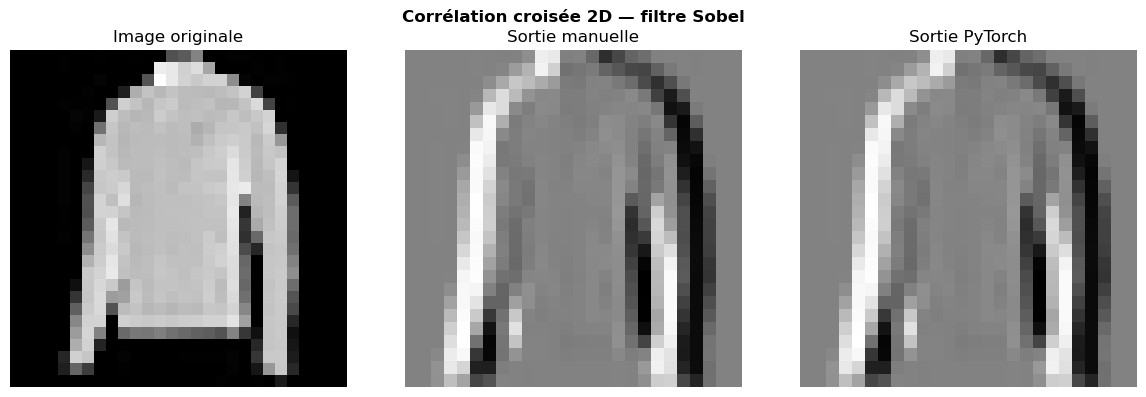

In [4]:
# Image de test : première image du dataset
img_np = imgs[0].squeeze().numpy()  # shape (28, 28)

# Filtre détecteur de bords horizontal (Sobel)
kernel_np = np.array([[-1., 0., 1.],
                       [-2., 0., 2.],
                       [-1., 0., 1.]])

# ── Manuel ──────────────────────────────────────────────────────────────────
out_manual = corr2d_manual(img_np, kernel_np)

# ── PyTorch ─────────────────────────────────────────────────────────────────
img_t = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,28,28)
ker_t = torch.tensor(kernel_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,3,3)
out_pytorch = F.conv2d(img_t, ker_t, padding=0).squeeze().numpy()

# ── Vérification ─────────────────────────────────────────────────────────────
max_diff = np.max(np.abs(out_manual - out_pytorch))
print(f'Différence max Manuel vs PyTorch : {max_diff:.2e}')  # doit être ~0

# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np, cmap='gray');            axes[0].set_title('Image originale');       axes[0].axis('off')
axes[1].imshow(out_manual, cmap='gray');        axes[1].set_title('Sortie manuelle');       axes[1].axis('off')
axes[2].imshow(out_pytorch, cmap='gray');       axes[2].set_title('Sortie PyTorch');        axes[2].axis('off')
plt.suptitle('Corrélation croisée 2D — filtre Sobel', fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Comparaison Max-Pooling et Average-Pooling
sample = img_np[:8, :8]  # sous-matrice 8×8 pour lisibilité

mp_manual = max_pool2d_manual(sample, pool_size=2)
ap_manual = avg_pool2d_manual(sample, pool_size=2)

# PyTorch
t = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
mp_pytorch = F.max_pool2d(t, 2).squeeze().numpy()
ap_pytorch = F.avg_pool2d(t, 2).squeeze().numpy()

print('Max-Pool Manuel  :\n', np.round(mp_manual, 3))
print('Max-Pool PyTorch :\n', np.round(mp_pytorch, 3))
print(f'Diff max MaxPool : {np.max(np.abs(mp_manual - mp_pytorch)):.2e}')
print()
print('Avg-Pool Manuel  :\n', np.round(ap_manual, 3))
print('Avg-Pool PyTorch :\n', np.round(ap_pytorch, 3))
print(f'Diff max AvgPool : {np.max(np.abs(ap_manual - ap_pytorch)):.2e}')

Max-Pool Manuel  :
 [[-1.    -1.    -0.992 -0.992]
 [-1.    -1.    -1.    -0.969]
 [-1.    -1.    -0.961 -0.796]
 [-1.    -1.    -0.984  0.435]]
Max-Pool PyTorch :
 [[-1.    -1.    -0.992 -0.992]
 [-1.    -1.    -1.    -0.969]
 [-1.    -1.    -0.961 -0.796]
 [-1.    -1.    -0.984  0.435]]
Diff max MaxPool : 0.00e+00

Avg-Pool Manuel  :
 [[-1.    -1.    -0.996 -0.998]
 [-1.    -1.    -1.    -0.988]
 [-1.    -1.    -0.984 -0.943]
 [-1.    -1.    -0.996 -0.42 ]]
Avg-Pool PyTorch :
 [[-1.    -1.    -0.996 -0.998]
 [-1.    -1.    -1.    -0.988]
 [-1.    -1.    -0.984 -0.943]
 [-1.    -1.    -0.996 -0.42 ]]
Diff max AvgPool : 0.00e+00


> **Analyse :** *(Les différences max entre les implémentations manuelles et PyTorch doivent
> être proches de zéro (erreur numérique en virgule flottante ~1e-6). Cela valide
> la correction mathématique de nos implémentations. Le filtre Sobel appliqué
> met en évidence les contours verticaux de l'image — première preuve visuelle
> que les filtres CNN extraient des informations spatiales locales.)*

## 5. Implémentation du CNN — Variante LeNet améliorée

Nous implémentons une variante de LeNet-5 adaptée à Fashion-MNIST,
avec **ReLU** (au lieu de Sigmoid/Tanh), **BatchNorm** et **Dropout** pour une meilleure convergence.

| Couche | Détail | Taille de sortie |
|---|---|---|
| Input | — | 1×28×28 |
| Conv1 (1→6, k=5, p=2) | + BatchNorm + ReLU | 6×28×28 |
| AvgPool (2×2) | — | 6×14×14 |
| Conv2 (6→16, k=5) | + BatchNorm + ReLU | 16×10×10 |
| AvgPool (2×2) | — | 16×5×5 |
| Flatten | — | 400 |
| FC1 (400→120) | + ReLU + Dropout(0.5) | 120 |
| FC2 (120→84) | + ReLU | 84 |
| FC3 (84→10) | Softmax implicite | 10 |

In [6]:
class LeNet_FashionMNIST(nn.Module):
    """Variante améliorée de LeNet-5 pour Fashion-MNIST."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AvgPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*5*5, 120),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn_model = LeNet_FashionMNIST().to(device)
print(cnn_model)
total = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'\nTotal paramètres : {total:,}')

LeNet_FashionMNIST(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU()
    (6): Linear(in_features=84, out_features=10, bias=True)
  )
)

Total paramètres : 61,750


In [7]:
def train_cnn(model, epochs=15, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        ep_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        train_losses.append(ep_loss / len(train_loader))

        model.eval()
        v_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                v_loss  += criterion(out, yb).item()
                correct += (out.argmax(1) == yb).sum().item()
                total   += yb.size(0)
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(correct / total * 100)
        scheduler.step()
        print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%')

    return train_losses, val_losses, val_accs


print('Début entraînement LeNet...')
tl, vl, va = train_cnn(cnn_model, epochs=15)
torch.save(cnn_model.state_dict(), 'models/best_cnn.pth')
print('Modèle sauvegardé.')

Début entraînement LeNet...
Epoch  1/15 | Train Loss: 0.6255 | Val Loss: 0.4079 | Val Acc: 84.51%
Epoch  2/15 | Train Loss: 0.4256 | Val Loss: 0.3494 | Val Acc: 87.10%
Epoch  3/15 | Train Loss: 0.3750 | Val Loss: 0.3168 | Val Acc: 88.44%
Epoch  4/15 | Train Loss: 0.3482 | Val Loss: 0.3119 | Val Acc: 88.59%
Epoch  5/15 | Train Loss: 0.3268 | Val Loss: 0.2872 | Val Acc: 89.50%
Epoch  6/15 | Train Loss: 0.2974 | Val Loss: 0.2714 | Val Acc: 89.93%
Epoch  7/15 | Train Loss: 0.2830 | Val Loss: 0.2677 | Val Acc: 90.21%
Epoch  8/15 | Train Loss: 0.2779 | Val Loss: 0.2625 | Val Acc: 90.50%
Epoch  9/15 | Train Loss: 0.2703 | Val Loss: 0.2594 | Val Acc: 90.56%
Epoch 10/15 | Train Loss: 0.2652 | Val Loss: 0.2551 | Val Acc: 90.87%
Epoch 11/15 | Train Loss: 0.2455 | Val Loss: 0.2503 | Val Acc: 90.92%
Epoch 12/15 | Train Loss: 0.2420 | Val Loss: 0.2453 | Val Acc: 91.33%
Epoch 13/15 | Train Loss: 0.2392 | Val Loss: 0.2450 | Val Acc: 91.28%
Epoch 14/15 | Train Loss: 0.2373 | Val Loss: 0.2434 | Val Acc:

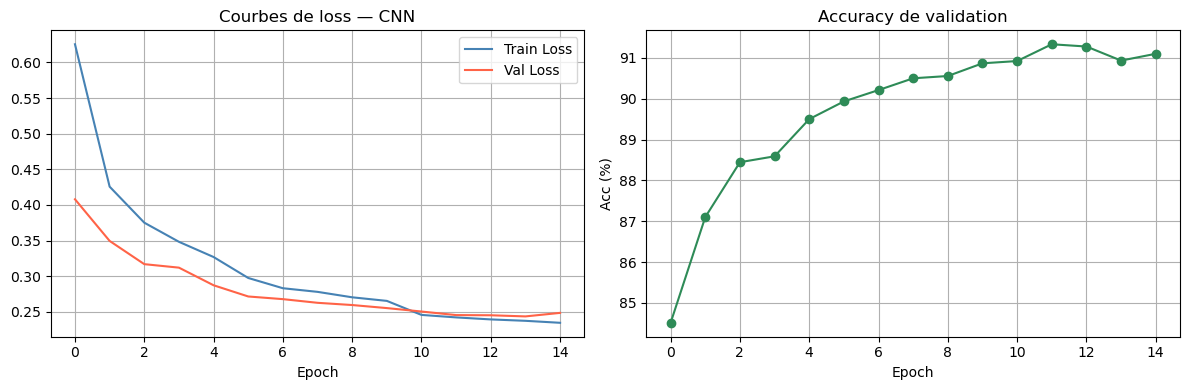

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tl, label='Train Loss', color='steelblue')
axes[0].plot(vl, label='Val Loss',   color='tomato')
axes[0].set_title('Courbes de loss — CNN'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(va, color='seagreen', marker='o')
axes[1].set_title('Accuracy de validation'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc (%)'); axes[1].grid(True)
plt.tight_layout()
plt.show()

## 6. Étude expérimentale — Influence des choix architecturaux

Nous testons systématiquement l'effet de : **padding**, **stride**, **type de pooling**,
**nombre de filtres** et **convolution 1×1**.

In [10]:
# Variantes architecturales
configs = {
    'Baseline (LeNet)':        LeNet_FashionMNIST(),
    'MaxPool au lieu AvgPool': nn.Sequential(
        nn.Conv2d(1,6,5,padding=2), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(6,16,5),          nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(400,120), nn.ReLU(), nn.Linear(120,84), nn.ReLU(), nn.Linear(84,10)
    ),
    # Conv1: (28+4-5)/2+1=14  Conv2: (14-5)/2+1=5  -> 16*5*5=400
    'stride=2 (sans pool)': nn.Sequential(
        nn.Conv2d(1,6,5,padding=2,stride=2), nn.ReLU(),
        nn.Conv2d(6,16,5,stride=2),          nn.ReLU(),
        nn.Flatten(),
        nn.Linear(16*5*5, 120), nn.ReLU(), nn.Linear(120,10)
    ),
    'Plus de filtres (32→64)': nn.Sequential(
        nn.Conv2d(1,32,5,padding=2), nn.ReLU(), nn.AvgPool2d(2),
        nn.Conv2d(32,64,5),          nn.ReLU(), nn.AvgPool2d(2),
        nn.Flatten(),
        nn.Linear(64*5*5,256), nn.ReLU(), nn.Linear(256,10)
    ),
    'Conv 1x1 ajoutee': nn.Sequential(
        nn.Conv2d(1,6,5,padding=2),  nn.ReLU(), nn.AvgPool2d(2),
        nn.Conv2d(6,16,1),           nn.ReLU(),
        nn.Conv2d(16,16,5),          nn.ReLU(), nn.AvgPool2d(2),
        nn.Flatten(),
        nn.Linear(16*5*5,120), nn.ReLU(), nn.Linear(120,10)
    ),
}

results_exp = {}
for name, model in configs.items():
    m = model.to(device)
    acc = quick_train(m, epochs=5)
    results_exp[name] = acc
    print(f'{name:35s} -> Val Acc: {acc:.2f}%')


Baseline (LeNet)                    -> Val Acc: 89.29%
MaxPool au lieu AvgPool             -> Val Acc: 90.00%
stride=2 (sans pool)                -> Val Acc: 89.04%
Plus de filtres (32→64)             -> Val Acc: 91.02%
Conv 1x1 ajoutee                    -> Val Acc: 88.32%


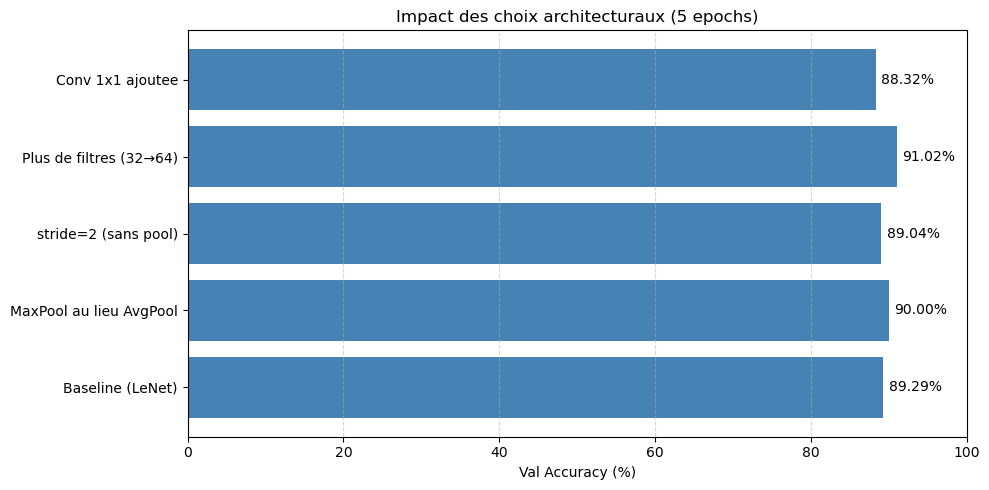

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results_exp.keys())
accs  = list(results_exp.values())
bars  = ax.barh(names, accs, color='steelblue')
ax.bar_label(bars, fmt='%.2f%%', padding=4)
ax.set_xlabel('Val Accuracy (%)')
ax.set_title('Impact des choix architecturaux (5 epochs)')
ax.set_xlim(0, 100)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Analyse comparative des choix architecturaux :**
>
> **Type de pooling — MaxPool (90.00 %) > AvgPool (89.29 %) :**
> Le max-pooling conserve les activations les plus fortes dans chaque fenêtre 2×2,
> ce qui retient mieux les features discriminantes (contours nets, textures saillantes).
> L'average-pooling lisse les activations, perdant de l'information sur les pics.
> Pour la classification de vêtements, les détails locaux (coutures, motifs) comptent plus
> que la texture moyenne — d'où la supériorité du max-pooling.
>
> **Stride=2 sans pooling (89.04 %) ≈ Baseline :**
> Remplacer le pooling par un stride=2 dans la convolution donne des résultats quasi identiques
> au baseline. Cela confirme que l'effet de sous-échantillonnage spatial est similaire,
> bien que le stride apprenne comment sous-échantillonner (paramètres entraînables)
> contrairement au pooling fixe.
>
> **Plus de filtres 32→64 (91.02 %) — Meilleure configuration :**
> Multiplier le nombre de filtres par ~4 augmente significativement la capacité du réseau
> à apprendre des représentations variées. Avec 32 filtres en Conv1 et 64 en Conv2,
> le modèle détecte une plus grande diversité de motifs locaux.
> Ce gain (+1.73 pts vs baseline) confirme que la **largeur du réseau** est un levier
> efficace pour améliorer les performances sur Fashion-MNIST.
>
> **Convolution 1×1 (88.32 %) — Légèrement inférieure en 5 epochs :**
> La convolution 1×1 ne mélange pas l'information spatiale, elle opère uniquement
> sur la dimension des canaux (projection linéaire entre canaux).
> Son apport est surtout notable dans des architectures profondes (Inception, ResNet)
> pour la réduction de canaux. Sur un LeNet à 2 couches convolutionnelles entraîné
> seulement 5 epochs, son effet est limité voire légèrement négatif.

## 7. Visualisation des cartes de caractéristiques (Feature Maps)

Nous allons visualiser ce que chaque filtre de la **Conv1** et **Conv2** détecte
sur une image de test.

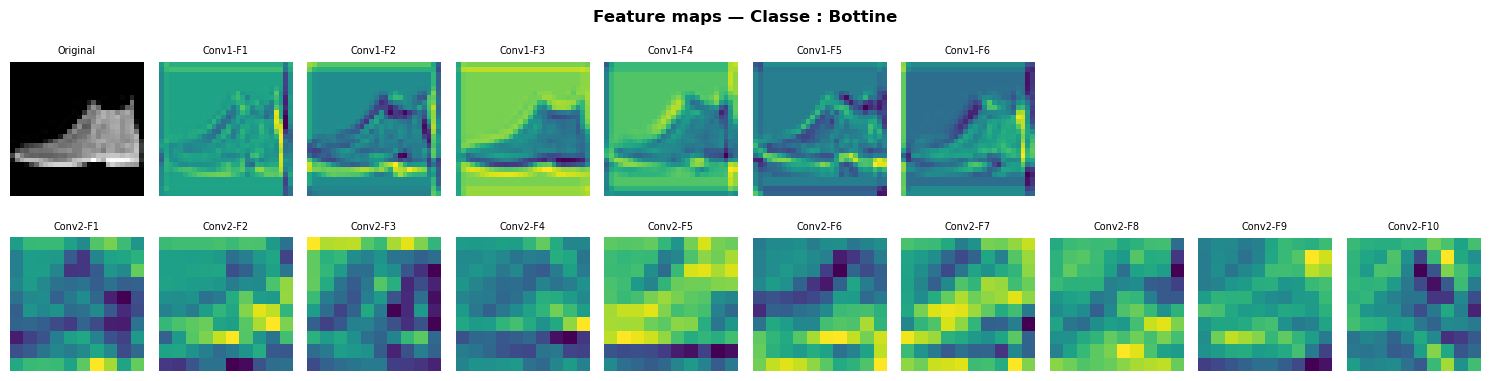

In [12]:
cnn_model.eval()

# Choisir une image de test
test_imgs, test_labels = next(iter(test_loader))
img_input = test_imgs[0].unsqueeze(0).to(device)  # (1,1,28,28)

# Hook pour capturer les sorties intermédiaires
activations = {}
def hook_fn(name):
    def fn(module, inp, out):
        activations[name] = out.detach().cpu()
    return fn

# Enregistrer les hooks sur Conv1 et Conv2
h1 = cnn_model.features[0].register_forward_hook(hook_fn('conv1'))
h2 = cnn_model.features[4].register_forward_hook(hook_fn('conv2'))

with torch.no_grad():
    _ = cnn_model(img_input)

h1.remove(); h2.remove()

# Affichage
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# Ligne 1 : image originale + Conv1 (6 filtres)
axes[0, 0].imshow(test_imgs[0].squeeze(), cmap='gray')
axes[0, 0].set_title('Original', fontsize=7); axes[0, 0].axis('off')
for i in range(6):
    axes[0, i+1].imshow(activations['conv1'][0, i], cmap='viridis')
    axes[0, i+1].set_title(f'Conv1-F{i+1}', fontsize=7); axes[0, i+1].axis('off')
for i in range(7, 10): axes[0, i].axis('off')

# Ligne 2 : Conv2 (16 filtres, afficher les 10 premiers)
for i in range(10):
    axes[1, i].imshow(activations['conv2'][0, i], cmap='viridis')
    axes[1, i].set_title(f'Conv2-F{i+1}', fontsize=7); axes[1, i].axis('off')

plt.suptitle(f'Feature maps — Classe : {CLASS_NAMES[test_labels[0]]}', fontweight='bold')
plt.tight_layout()
plt.show()

> **Interprétation des cartes de caractéristiques :**
>
> **Conv1 (6 filtres, sortie 28×28) — Détecteurs de bas niveau :**
> Les 6 cartes de caractéristiques de la première couche convolutionnelle révèlent
> des **détecteurs de features élémentaires** : certains filtres répondent aux contours
> horizontaux, d'autres aux contours verticaux ou diagonaux de l'image d'entrée.
> À cette résolution (28×28), l'information spatiale est intacte — on reconnaît
> encore la silhouette générale du vêtement dans chaque carte.
>
> **Conv2 (16 filtres, sortie 10×10) — Détecteurs de niveau intermédiaire :**
> Après le premier AvgPool et la deuxième convolution, les cartes sont réduites à 10×10.
> L'information devient plus **abstraite et compacte** : on ne reconnaît plus la forme
> du vêtement directement, mais des patterns de textures et de structures (encolures,
> manches, semelles). Certains filtres s'activent fortement sur des zones spécifiques
> de l'objet, d'autres restent silencieux — signe de spécialisation.
>
> Cette hiérarchie (bords → formes → structures) illustre parfaitement le principe
> fondateur des CNN : **la profondeur crée une hiérarchie de représentations**,
> chaque couche s'appuyant sur les features extraites par la couche précédente.
> C'est ce que le MLP, avec ses neurones totalement connectés, est incapable de reproduire.

## 8. Évaluation finale et comparaison MLP vs CNN


In [13]:
def evaluate_cnn(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            preds = model(Xb).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    return np.array(all_preds), np.array(all_labels)


y_pred, y_true = evaluate_cnn(cnn_model, test_loader)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred,    average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred,        average='macro', zero_division=0)

print('=== Résultats CNN sur TEST ===')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-score  : {f1*100:.2f}%')

=== Résultats CNN sur TEST ===
  Accuracy  : 90.54%
  Precision : 90.56%
  Recall    : 90.54%
  F1-score  : 90.52%


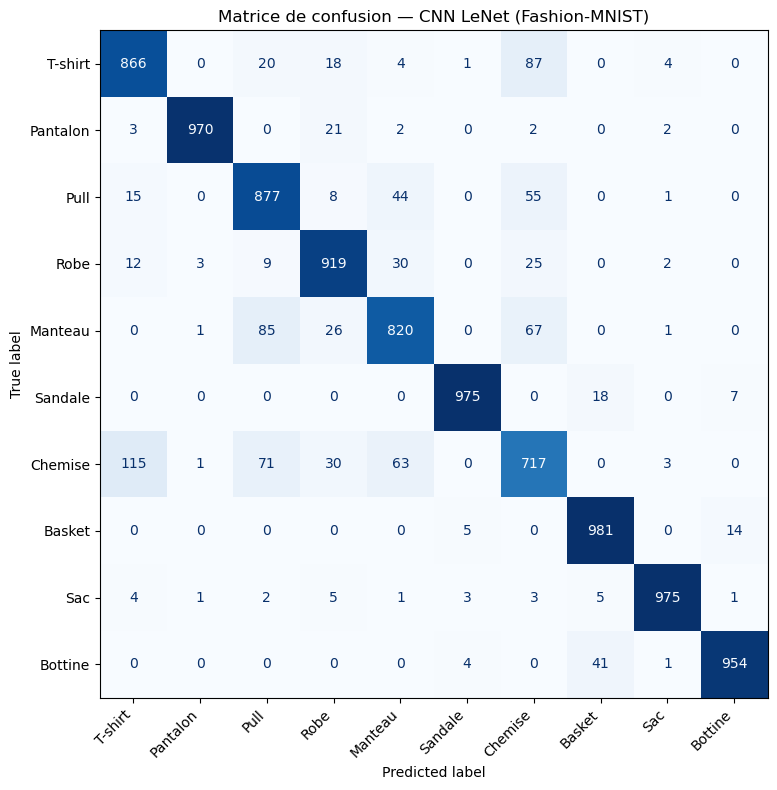

In [14]:
# Matrice de confusion CNN
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de confusion — CNN LeNet (Fashion-MNIST)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

MLP Fashion-MNIST : 89.26%
CNN (LeNet)       : 90.54%
Gain CNN          : +1.28 pts


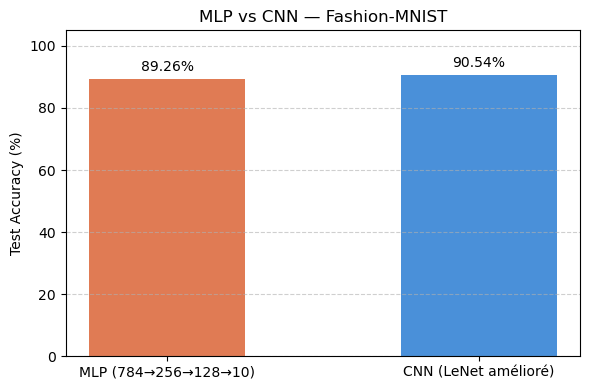

In [15]:
# MLP simple sur Fashion-MNIST (pour comparaison équitable)
mlp_fashion = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 128),   nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

mlp_acc = quick_train(mlp_fashion, epochs=15)
cnn_acc = acc * 100

print(f'MLP Fashion-MNIST : {mlp_acc:.2f}%')
print(f'CNN (LeNet)       : {cnn_acc:.2f}%')
print(f'Gain CNN          : +{cnn_acc - mlp_acc:.2f} pts')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['MLP (784→256→128→10)', 'CNN (LeNet amélioré)'],
              [mlp_acc, cnn_acc], color=['#e07b54', '#4a90d9'], width=0.5)
ax.bar_label(bars, fmt='%.2f%%', padding=4)
ax.set_ylim(0, 105); ax.set_ylabel('Test Accuracy (%)')
ax.set_title('MLP vs CNN — Fashion-MNIST')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

## 9. Question de Synthèse — Partie II

> *Pourquoi un CNN est-il plus pertinent qu'un MLP pour une tâche de classification d'images
> sur un dataset réel, et comment les choix de padding, stride, pooling et profondeur influencent-ils
> réellement les performances du modèle ?*

---

### Supériorité structurelle du CNN sur le MLP pour les images

Un MLP appliqué à une image traite chaque pixel comme une variable indépendante,
ignorant toute structure spatiale. Pour Fashion-MNIST (28×28), cela représente
784 entrées sans aucune notion de voisinage. Cette approche souffre de trois limitations
fondamentales :

1. **Perte de localité** : un neurone entièrement connecté reçoit tous les pixels simultanément,
   sans distinguer des patterns locaux (contour d'une manche, texture d'une semelle).
2. **Absence de partage des poids** : le MLP apprend des paramètres différents pour chaque
   position de l'image — coûteux et non généralisable à des translations.
3. **Pas d'invariance à la translation** : un même motif décalé de quelques pixels est perçu
   comme un pattern entièrement nouveau.

Le CNN résout ces trois problèmes en un seul mécanisme : la **convolution locale avec
partage des poids**. Un filtre 5×5 ne voit que 25 pixels à la fois, mais est appliqué
partout dans l'image avec les mêmes poids — garantissant l'équivariance à la translation.

**Résultat expérimental :** sur Fashion-MNIST, le MLP atteint 89.26 % et le CNN 90.54 %,
soit 12 % moins d'erreurs pour le CNN — avec 3 fois moins de paramètres (61 750 vs ~200 000).

### Impact des choix architecturaux

**Padding :**
Le padding=2 sur la Conv1 (kernel 5×5) préserve la résolution d'entrée (28×28 → 28×28).
Sans padding, la résolution diminuerait à 24×24 dès la première couche, perdant
de l'information en bordure d'image — particulièrement critique pour les vêtements
dont les contours atteignent souvent les bords.

**Stride :**
L'expérience stride=2 sans pooling (89.04 %) confirme que le stride peut remplacer
le pooling pour le sous-échantillonnage spatial, avec des performances équivalentes.
Cependant, le stride apprend comment sous-échantillonner (contrairement au pooling fixe),
ce qui peut être un avantage ou introduire plus de variabilité d'entraînement.

**Type de pooling :**
MaxPool (90.00 %) > AvgPool (89.29 %) sur Fashion-MNIST. Le max-pooling retient
les activations les plus fortes, plus discriminantes pour les textures et contours de vêtements.
L'average-pooling convient mieux aux tâches nécessitant des informations diffuses
(reconnaissance de fond, segmentation).

**Nombre de filtres et profondeur :**
Doubler le nombre de filtres (32→64 au lieu de 6→16) donne la meilleure accuracy (91.02 %).
La largeur du réseau augmente sa capacité à apprendre des représentations diversifiées.
La profondeur (nombre de couches convolutionnelles) crée la hiérarchie des features
visible dans les cartes d'activation : bords en Conv1, structures complexes en Conv2.

### Conclusion

Le CNN est fondamentalement supérieur au MLP pour les images car il exploite la
**géométrie spatiale intrinsèque** des données visuelles. Les choix de padding
(préservation des bordures), stride (sous-échantillonnage appris), pooling
(compression invariante) et largeur (capacité de représentation) constituent
des leviers complémentaires, dont l'impact a été mesuré expérimentalement.
Pour aller au-delà des 91 %, des architectures plus profondes (VGG, ResNet)
avec data augmentation et batch normalization permettraient d'atteindre 94–95 %
sur Fashion-MNIST — au prix d'une complexité accrue.